In [1]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
#data loading

data1 = pd.read_csv('train.csv')
data2 = pd.read_csv('test.csv')

train_df = data1.copy()
test_df = data2.copy()

print("First 5 rows of train_df: \n", train_df.head())

print("First 5 rows of test_df: \n", test_df.head())

First 5 rows of train_df: 
    id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0              

In [3]:
train_df = train_df.drop(columns=['id'], axis=1)

test_id_placeholder = test_df['id']
test_df = test_df.drop(columns=['id'], axis=1)

In [4]:
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

In [5]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

X = train_df.drop(columns='loan_paid_back')
y = train_df['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
cat_model = CatBoostClassifier(cat_features=cat_cols)

cat_model.fit(X_train, y_train)

Learning rate set to 0.143205
0:	learn: 0.5405242	total: 375ms	remaining: 6m 14s
1:	learn: 0.4433729	total: 597ms	remaining: 4m 57s
2:	learn: 0.3802827	total: 804ms	remaining: 4m 27s
3:	learn: 0.3410668	total: 1.05s	remaining: 4m 21s
4:	learn: 0.3153787	total: 1.29s	remaining: 4m 17s
5:	learn: 0.2976656	total: 1.54s	remaining: 4m 16s
6:	learn: 0.2869880	total: 1.74s	remaining: 4m 6s
7:	learn: 0.2783549	total: 1.96s	remaining: 4m 3s
8:	learn: 0.2725982	total: 2.15s	remaining: 3m 57s
9:	learn: 0.2684360	total: 2.4s	remaining: 3m 57s
10:	learn: 0.2655688	total: 2.64s	remaining: 3m 57s
11:	learn: 0.2634373	total: 2.88s	remaining: 3m 57s
12:	learn: 0.2613712	total: 3.13s	remaining: 3m 57s
13:	learn: 0.2598790	total: 3.36s	remaining: 3m 56s
14:	learn: 0.2589231	total: 3.59s	remaining: 3m 55s
15:	learn: 0.2582219	total: 3.83s	remaining: 3m 55s
16:	learn: 0.2578017	total: 4.07s	remaining: 3m 55s
17:	learn: 0.2572070	total: 4.3s	remaining: 3m 54s
18:	learn: 0.2567331	total: 4.55s	remaining: 3m 

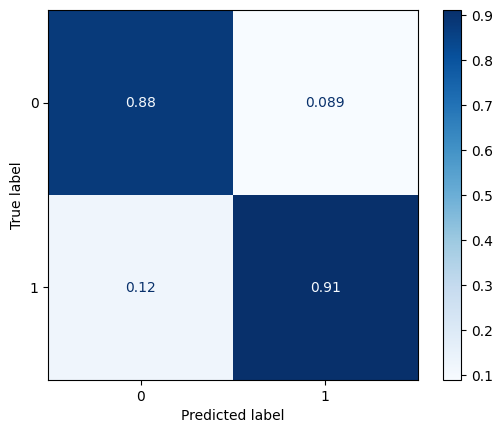

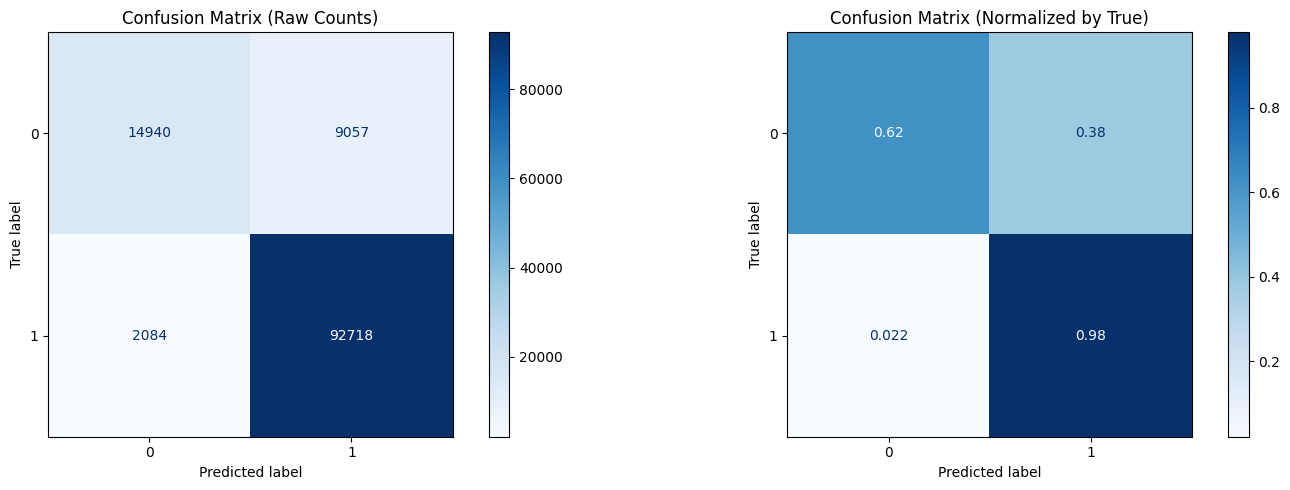

In [7]:
y_true = y_test

y_pred = cat_model.predict(X_test)


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred, normalize='pred')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

# Confusion matrix with different normalization options
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Raw counts
cm_raw = confusion_matrix(y_true, y_pred)
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm_raw)
disp_raw.plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix (Raw Counts)')

# Normalized by true labels (shows recall)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
disp_norm.plot(ax=ax2, cmap='Blues')
ax2.set_title('Confusion Matrix (Normalized by True)')

plt.tight_layout()
plt.show()


In [8]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Basic metrics
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-Score:", f1_score(y_true, y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.9062197493244892
Precision: 0.9110095799557848
Recall: 0.9780173414062995
F1-Score: 0.9433250075034211

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.62      0.73     23997
         1.0       0.91      0.98      0.94     94802

    accuracy                           0.91    118799
   macro avg       0.89      0.80      0.84    118799
weighted avg       0.90      0.91      0.90    118799



In [9]:
# X_submission = test_df.copy()

# test_pred = cat_model.predict(test_df)

# submission_df = pd.DataFrame({
#     "id": test_id_placeholder,
#     "loan_paid_back": test_pred
# })

# submission_df.to_csv('submission2.csv',index=False)
# print("Success!")

In [10]:
# from sklearn.model_selection import StratifiedKFold,train_test_split
# from catboost import CatBoostClassifier, Pool
# from sklearn.metrics import roc_auc_score
# import optuna

In [ ]:
# def objective(trial):
#     params = {
#         'iterations': trial.suggest_int('iterations', 500, 2500),
#         'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.1),
#         'depth': trial.suggest_int('depth', 4, 10),
#         'l2_leaf_reg': trial.suggest_loguniform('l2_leaf_reg', 1e-3, 10.0),
#         'random_state': 42,
#         'eval_metric': 'AUC',
#         'verbose': 0,
#         'early_stopping_rounds': 50,
#         'task_type': 'CPU',
#         'devices': '0'
#     }
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#     train_pool = Pool(X_train, y_train, cat_features=cat_cols)
#     test_pool = Pool(X_test, y_test, cat_features=cat_cols)
#     model = CatBoostClassifier(**params)
#     model.fit(train_pool, eval_set=test_pool)
#     y_prob = model.predict_proba(X_test)[:, 1]
#     roc_auc = roc_auc_score(y_test, y_prob)

#     return roc_auc

In [12]:
# study = optuna.create_study(direction='maximize')

# study.optimize(
#     objective,
#     n_trials=20,           
#     timeout=1800,        
#     show_progress_bar=True
# )

# print(f"Best score: {study.best_value}")
# print(f"Best params: {study.best_params}")

In [13]:
# study.best_params

In [14]:
# from sklearn.model_selection import cross_val_score

In [15]:
# params = {
#     'iterations': 2089,
#  'learning_rate': 0.04363991799567954,
#  'depth': 8,
#  'l2_leaf_reg': 0.016446005747259584
# }

# hyper_cat = CatBoostClassifier(**params, cat_features=cat_cols)

# cv_res = cross_val_score(hyper_cat, X_train, y_train, cv=3, scoring='neg_log_loss')

# print(f"Final CV scores: {cv_res}")
# print(f"Mean CV score: {cv_res.mean():.4f} ± {cv_res.std():.4f}")

# hyper_cat.fit(X_train, y_train)

In [16]:
# X_submission = test_df.copy()

# test_pred = hyper_cat.predict(X_submission)

# submission_df = pd.DataFrame({
#     "id": test_id_placeholder,
#     "loan_paid_back": test_pred
# })

# submission_df.to_csv('submission4.csv',index=False)
# print("Success!")